# Week 16 — Friday (Jul 13): PROJECT — Depth-Aware Background Blur (MiDaS + SAM)

## Project Goal
Bring together this week's monocular depth pipeline (Tuesday, MiDaS) with a promptable foreground
segmentation mask to build a **depth-graded background blur** — the computational-photography
effect behind phone "portrait mode": pixels far from the camera, per MiDaS's relative depth, get
progressively blurred, while the segmented subject stays sharp regardless of what the depth network
alone would have done to it. It stands on the rest of the week's geometric reasoning too: MiDaS's
relative depth is the same signal Monday's stereo disparity map gives (up to an unknown scale/shift),
and a depth + mask pixel grid like the one built here is exactly the input Wednesday's
back-projection step turns into a 3D point cloud.

## Learning Objectives
- Reuse a pretrained MiDaS depth model (same `torch.hub` pipeline as Tuesday) to get a per-pixel relative depth map for a real photo
- Understand what Segment Anything (SAM) contributes to a pipeline like this — promptable, zero-shot, class-agnostic instance masks — and why downloading/running a full SAM checkpoint is not practical on this CPU-only machine; implement a classical **GrabCut** stand-in instead, and say so honestly
- Fuse a depth map and a foreground mask into a single continuous **blur-radius map**: far-from-camera pixels get more blur, masked foreground pixels stay sharp regardless of their raw depth value
- Implement variable-radius ("space-varying") blur efficiently as a per-pixel blend across a precomputed Gaussian blur stack, instead of one blur pass per pixel
- Compare the depth-aware result quantitatively (variance-of-Laplacian sharpness) and qualitatively against naive whole-image blur and binary mask-only blur

## Pipeline
1. **Depth** — MiDaS_small on a real photo (same code path as Tuesday's notebook)
2. **Segmentation (SAM stand-in)** — GrabCut foreground/background segmentation, with an honest note on why real SAM isn't used here
3. **Fusion** — combine depth + mask into one blur-radius map
4. **Render** — depth-graded Gaussian blur via a blur stack + per-pixel blend
5. **Evaluate** — naive vs mask-only vs depth-aware blur, sharpness comparison

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn.functional as F
import cv2
from skimage import data as skdata

plt.rcParams['figure.figsize'] = (14, 6)
np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | OpenCV {cv2.__version__} | Device: {DEVICE}')
print('Week 16 - Friday: PROJECT - Depth-Aware Background Blur (MiDaS + SAM)')

PyTorch 2.12.0+cpu | OpenCV 4.13.0 | Device: cpu
Week 16 - Friday: PROJECT - Depth-Aware Background Blur (MiDaS + SAM)


## Section 1: Depth — Reuse MiDaS on a Real Photo

Same `MiDaS_small` model and `predict_depth()` pattern as Tuesday's notebook: a single RGB image
in, a per-pixel **relative inverse-depth** map out (larger value = closer to the camera). We swap
in a new subject — a close-up cat photo (`skimage.data.chelsea`) — because a clear
foreground-subject-against-background photo is exactly the case this project's blur effect is
built for.

Using cache found in C:\Users\User/.cache\torch\hub\intel-isl_MiDaS_master


Loading weights:  None


Using cache found in C:\Users\User/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master


Using cache found in C:\Users\User/.cache\torch\hub\intel-isl_MiDaS_master


Photo: (300, 451, 3) | Depth range: [-24.97, 1083.80]


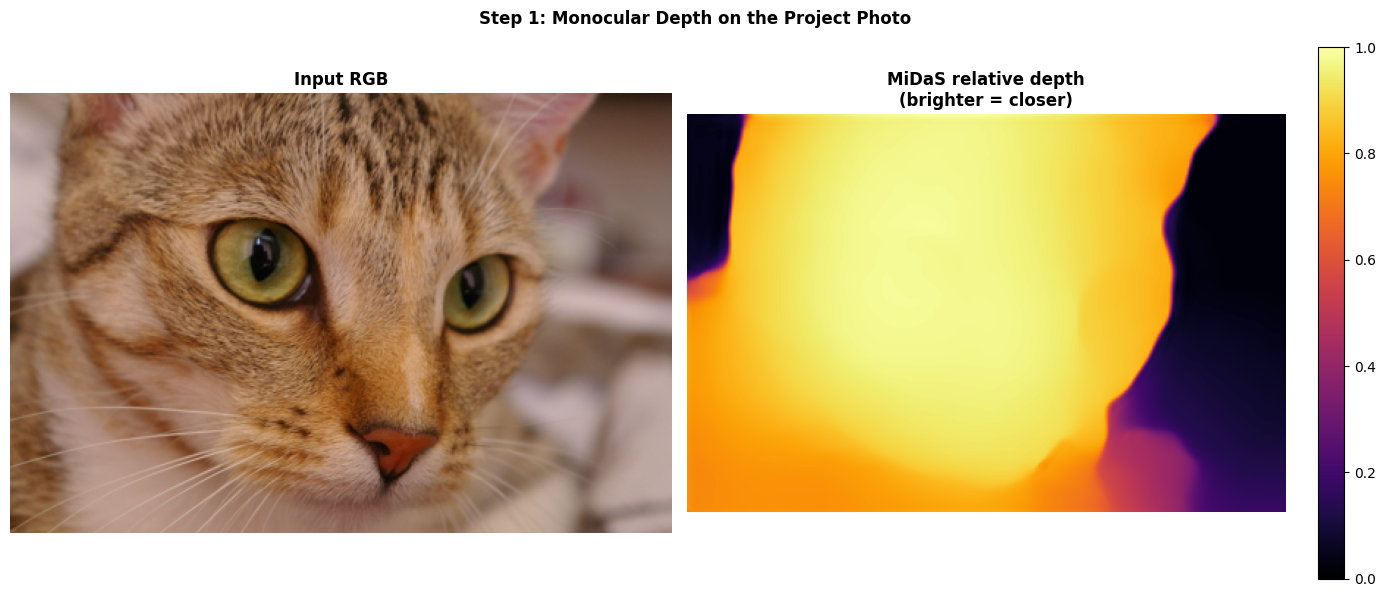

Saved depth_blur_input_depth.png


In [2]:
# ── Load pretrained MiDaS_small (cached from Tuesday's run) + a real subject photo ─
midas = torch.hub.load('intel-isl/MiDaS', 'MiDaS_small', trust_repo=True).to(DEVICE).eval()
midas_transforms = torch.hub.load('intel-isl/MiDaS', 'transforms', trust_repo=True)
transform = midas_transforms.small_transform

def predict_depth(img_rgb_uint8):
    """img_rgb_uint8: HxWx3 uint8 -> HxW float32 relative inverse-depth map (larger = closer)."""
    inp = transform(img_rgb_uint8).to(DEVICE)
    with torch.no_grad():
        pred = midas(inp)
        pred = F.interpolate(pred.unsqueeze(1), size=img_rgb_uint8.shape[:2],
                              mode='bicubic', align_corners=False).squeeze()
    return pred.cpu().numpy()

photo = skdata.chelsea()   # real 300x451x3 close-up photo (scikit-image sample) — cat = clear subject
depth = predict_depth(photo)
d_norm = (depth - depth.min()) / (depth.max() - depth.min() + 1e-8)   # 1 = closest, 0 = farthest
print(f'Photo: {photo.shape} | Depth range: [{depth.min():.2f}, {depth.max():.2f}]')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(photo); axes[0].set_title('Input RGB', fontweight='bold'); axes[0].axis('off')
im = axes[1].imshow(d_norm, cmap='inferno')
axes[1].set_title('MiDaS relative depth\n(brighter = closer)', fontweight='bold'); axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046)
plt.suptitle('Step 1: Monocular Depth on the Project Photo', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('depth_blur_input_depth.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved depth_blur_input_depth.png')

## Section 2: Segmentation — a SAM Stand-In

**SAM** (Kirillov et al., 2023) would normally give us this mask: click/box a point on the subject
and SAM returns a pixel-accurate, class-agnostic foreground mask, zero-shot, for *any* object —
no training on cats specifically required. That's exactly the mask this project needs.

> **Honest constraint note**: this machine is CPU-only with no `jupyter`-side GPU, and the smallest
> official SAM checkpoint (`vit_b`, ~375MB) plus its dependency (`segment-anything`) is a heavy,
> slow download/inference path for a CPU here — the same class of constraint this repo hits with
> full SAM training runs, e.g. how the NeRF/3DGS notebook uses a tiny 2D coordinate-MLP instead of
> real 3D NeRF training, or how Pix2Pix/CycleGAN notebooks train on small toy subsets instead of the
> full-scale datasets. So instead of a real SAM checkpoint, we use **GrabCut**
(Rother et al., 2004) — a classical, iterative graph-cut segmentation algorithm already built into
OpenCV — seeded with a bounding rectangle around the subject. It plays the *same role* in the
pipeline (RGB image in, binary foreground mask out) even though the underlying method is decades
older and needs a rough box instead of SAM's flexible point/box/mask prompts.

Foreground fraction: 34.50%


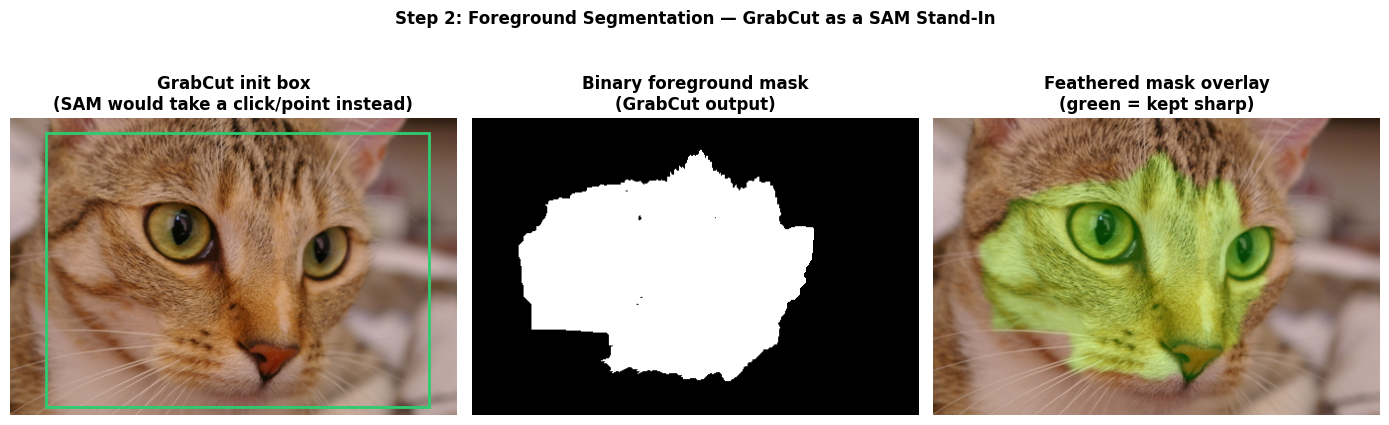

Saved depth_blur_sam_standin_mask.png


In [3]:
# ── GrabCut foreground segmentation (SAM stand-in — same role: RGB -> foreground mask) ─
H, W = photo.shape[:2]
gc_mask = np.zeros((H, W), np.uint8)
bgd_model = np.zeros((1, 65), np.float64)
fgd_model = np.zeros((1, 65), np.float64)
rect = (int(W * 0.08), int(H * 0.05), int(W * 0.86), int(H * 0.92))   # rough box around the subject

img_bgr = cv2.cvtColor(photo, cv2.COLOR_RGB2BGR)
cv2.grabCut(img_bgr, gc_mask, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)
fg_mask = np.where((gc_mask == cv2.GC_FGD) | (gc_mask == cv2.GC_PR_FGD), 1.0, 0.0).astype(np.float32)
fg_mask_soft = cv2.GaussianBlur(fg_mask, (0, 0), sigmaX=3)   # feather the mask edge
print(f'Foreground fraction: {fg_mask.mean():.2%}')

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(photo); axes[0].add_patch(plt.Rectangle((rect[0], rect[1]), rect[2], rect[3],
              edgecolor='#2ecc71', facecolor='none', lw=2))
axes[0].set_title('GrabCut init box\n(SAM would take a click/point instead)', fontweight='bold'); axes[0].axis('off')
axes[1].imshow(fg_mask, cmap='gray')
axes[1].set_title('Binary foreground mask\n(GrabCut output)', fontweight='bold'); axes[1].axis('off')
overlay = photo.copy().astype(np.float32)
overlay[..., 1] = np.clip(overlay[..., 1] + fg_mask_soft * 60, 0, 255)
axes[2].imshow(overlay.astype(np.uint8))
axes[2].set_title('Feathered mask overlay\n(green = kept sharp)', fontweight='bold'); axes[2].axis('off')
plt.suptitle('Step 2: Foreground Segmentation — GrabCut as a SAM Stand-In', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('depth_blur_sam_standin_mask.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved depth_blur_sam_standin_mask.png')

## Section 3: Fusion — Depth + Mask -> a Blur-Radius Map

This is the actual "fusion" step of the project: depth alone doesn't know which object is the
*subject* (a background object at the same distance as an outstretched hand would get the same
depth value), and the mask alone has no notion of *how much* to blur what's outside it — it's
binary. Combining them fixes both:

$$\text{blur}(x, y) = \big(1 - d_{\text{norm}}(x, y)\big) \times \big(1 - \text{mask}_{\text{soft}}(x, y)\big)$$

- $(1 - d_{\text{norm}})$ — farther-from-camera pixels (small relative depth) get a **larger** blur amount
- $(1 - \text{mask}_{\text{soft}})$ — gates that amount to zero inside the segmented subject, regardless of what its own depth value says, so the whole subject stays crisp even where it dips slightly closer/farther than average

Blur-amount map range: [0.000, 1.000]


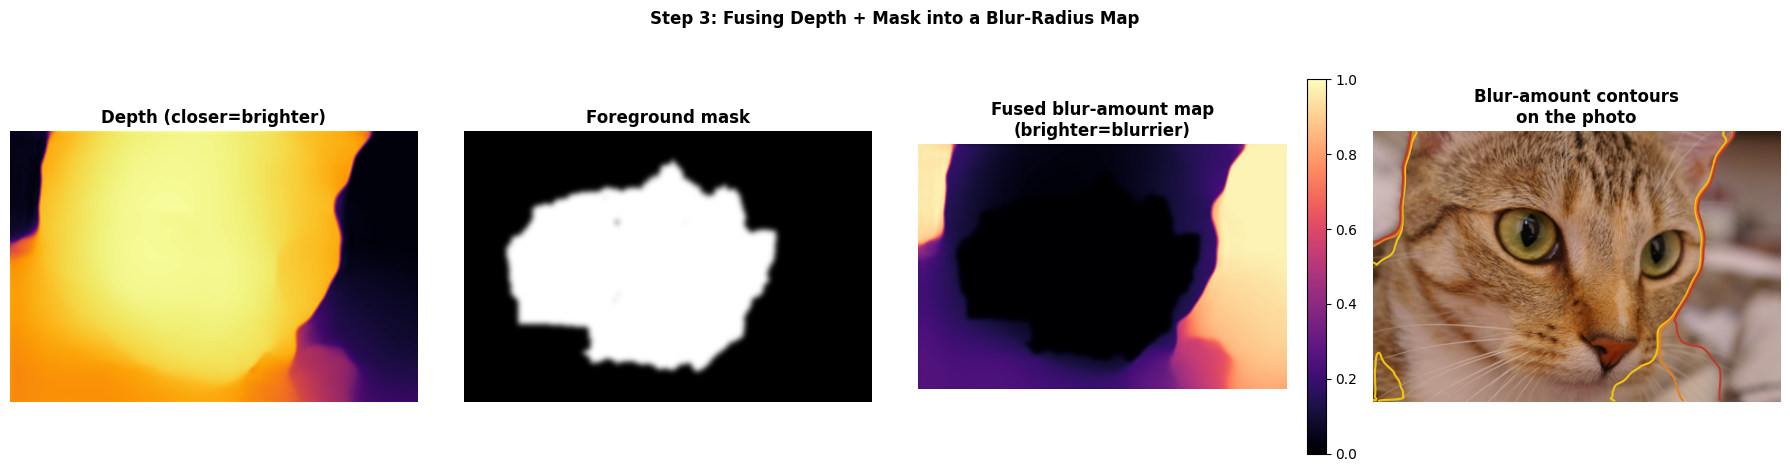

Saved depth_blur_radius_map.png


In [4]:
# ── Fuse depth + mask into one continuous blur-amount map in [0, 1] ────────────
blur_amount = (1 - d_norm) * (1 - fg_mask_soft)
print(f'Blur-amount map range: [{blur_amount.min():.3f}, {blur_amount.max():.3f}]')

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(d_norm, cmap='inferno'); axes[0].set_title('Depth (closer=brighter)', fontweight='bold'); axes[0].axis('off')
axes[1].imshow(fg_mask_soft, cmap='gray'); axes[1].set_title('Foreground mask', fontweight='bold'); axes[1].axis('off')
im = axes[2].imshow(blur_amount, cmap='magma'); axes[2].set_title('Fused blur-amount map\n(brighter=blurrier)', fontweight='bold'); axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046)
axes[3].imshow(photo)
axes[3].contour(blur_amount, levels=[0.25, 0.5, 0.75], colors=['#f1c40f', '#e67e22', '#c0392b'], linewidths=1.5)
axes[3].set_title('Blur-amount contours\non the photo', fontweight='bold'); axes[3].axis('off')
plt.suptitle('Step 3: Fusing Depth + Mask into a Blur-Radius Map', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('depth_blur_radius_map.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved depth_blur_radius_map.png')

## Section 4: Render — Depth-Graded Variable Blur (Bokeh)

A different Gaussian blur radius *per pixel* is expensive if done naively (a separate convolution
for every pixel). The standard trick — used here — is to precompute a small **blur stack**:
the same image blurred at a handful of increasing sigmas, then blend between the two nearest
stack levels **per pixel** according to its `blur_amount` value (linear interpolation in blur-level
space). This turns an O(pixels × kernel) variable-blur problem into `N_LEVELS` fixed convolutions
plus one cheap per-pixel blend.

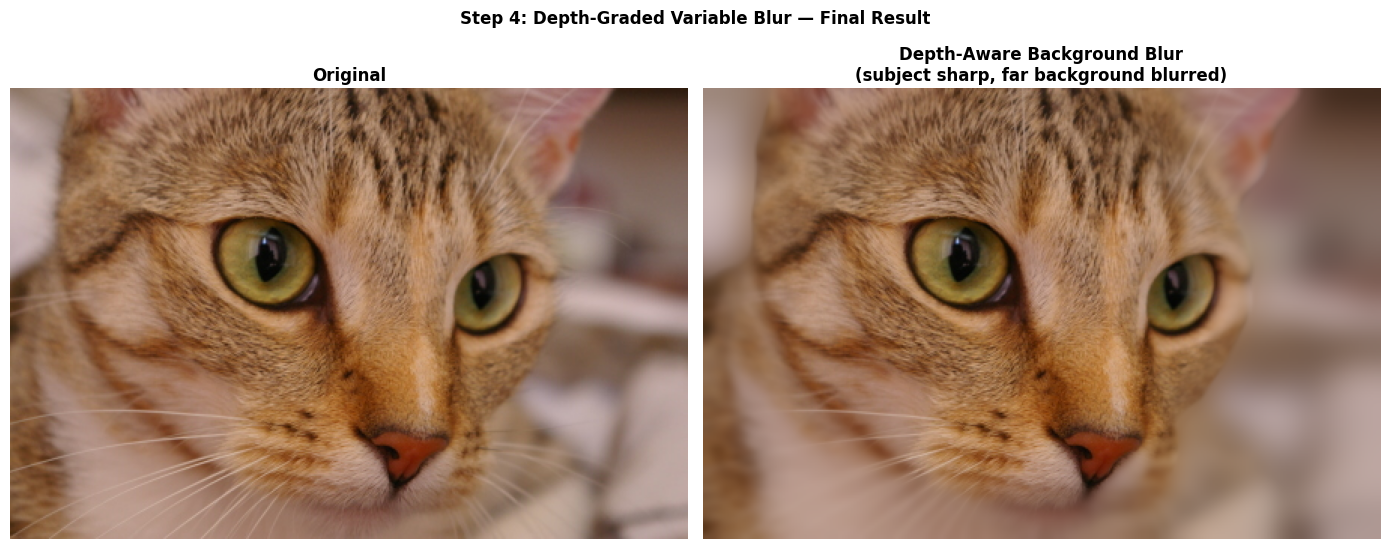

Saved depth_blur_result.png


In [5]:
# ── Depth-graded blur: precompute a blur stack, blend per-pixel by blur_amount ──
N_LEVELS = 6
MAX_SIGMA = 12
sigmas = np.linspace(0, MAX_SIGMA, N_LEVELS)

stack = [photo.astype(np.float32)]
for s in sigmas[1:]:
    stack.append(cv2.GaussianBlur(photo.astype(np.float32), (0, 0), sigmaX=s))
stack = np.stack(stack, axis=0)   # (N_LEVELS, H, W, 3)

level_f = blur_amount * (N_LEVELS - 1)          # continuous blur-stack index per pixel
level_lo = np.floor(level_f).astype(int)
level_hi = np.clip(level_lo + 1, 0, N_LEVELS - 1)
frac = (level_f - level_lo)[..., None]

idx_lo = level_lo[None, ..., None].repeat(3, axis=-1)
idx_hi = level_hi[None, ..., None].repeat(3, axis=-1)
lo_img = np.take_along_axis(stack, idx_lo, axis=0)[0]
hi_img = np.take_along_axis(stack, idx_hi, axis=0)[0]
depth_aware_blur = np.clip(lo_img * (1 - frac) + hi_img * frac, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(photo); axes[0].set_title('Original', fontweight='bold'); axes[0].axis('off')
axes[1].imshow(depth_aware_blur); axes[1].set_title('Depth-Aware Background Blur\n(subject sharp, far background blurred)', fontweight='bold'); axes[1].axis('off')
plt.suptitle('Step 4: Depth-Graded Variable Blur — Final Result', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('depth_blur_result.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved depth_blur_result.png')

## Section 5: Evaluate — Naive vs Mask-Only vs Depth-Aware Blur

Three baselines, from crudest to the project's full pipeline:

1. **Naive** — one uniform Gaussian blur over the *whole* image (no mask, no depth) — blurs the subject too
2. **Mask-only** — binary: sharp inside the mask, one fixed blur level everywhere outside it — no sense of *how far* the background actually is
3. **Depth-aware (this project)** — sharp inside the mask, and a **continuously graded** blur outside it that follows the scene's actual depth

We score each with **variance of the Laplacian** on the foreground region (a standard focus/sharpness
metric — a sharp, detailed image has high-variance second derivatives; a blurred one is low).

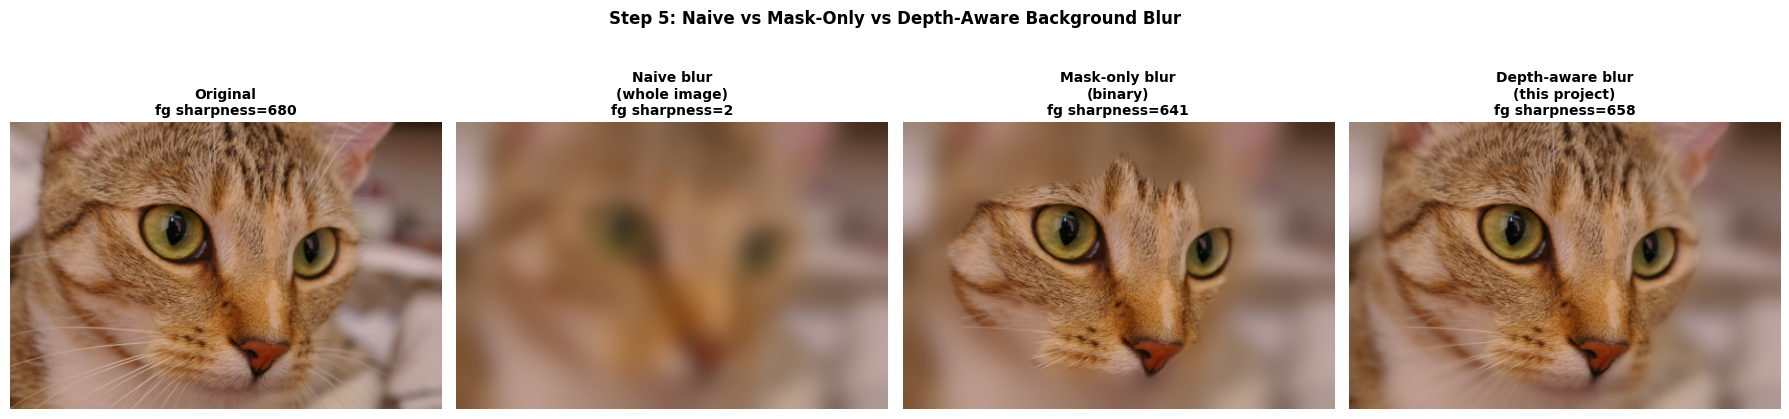

Saved depth_blur_comparison.png
Original: foreground sharpness = 679.6
Naive blur (whole image): foreground sharpness = 1.7
Mask-only blur (binary): foreground sharpness = 641.3
Depth-aware blur (this project): foreground sharpness = 657.7


In [6]:
# ── Compare against naive whole-image blur and binary mask-only blur ──────────
def sharpness(img_rgb, region_mask):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    lap = cv2.Laplacian(gray, cv2.CV_64F)
    return lap[region_mask > 0.5].var()

naive_blur = cv2.GaussianBlur(photo.astype(np.float32), (0, 0), sigmaX=MAX_SIGMA)
naive_blur = np.clip(naive_blur, 0, 255).astype(np.uint8)

mask_only = photo.astype(np.float32) * fg_mask_soft[..., None] + naive_blur.astype(np.float32) * (1 - fg_mask_soft[..., None])
mask_only = np.clip(mask_only, 0, 255).astype(np.uint8)

results = {
    'Original': photo,
    'Naive blur\n(whole image)': naive_blur,
    'Mask-only blur\n(binary)': mask_only,
    'Depth-aware blur\n(this project)': depth_aware_blur,
}
scores = {name: sharpness(img, fg_mask) for name, img in results.items()}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, (name, img) in zip(axes, results.items()):
    ax.imshow(img); ax.axis('off')
    ax.set_title(f'{name}\nfg sharpness={scores[name]:.0f}', fontweight='bold', fontsize=10)
plt.suptitle('Step 5: Naive vs Mask-Only vs Depth-Aware Background Blur', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('depth_blur_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved depth_blur_comparison.png')
for name, s in scores.items():
    print(f'{name.replace(chr(10), " ")}: foreground sharpness = {s:.1f}')

## Summary

| Concept | Summary |
|---------|--------|
| **Depth-aware background blur** | Fuses a per-pixel relative depth map with a foreground mask into one continuous blur-radius map — the mechanism behind phone "portrait mode" |
| **MiDaS reuse** | Same `torch.hub` `MiDaS_small` model and `predict_depth()` pattern as Tuesday's notebook — relative, scale/shift-invariant depth, not metric |
| **SAM's role** | Promptable, zero-shot, class-agnostic foreground masks. Not run here (CPU-only machine, checkpoint too heavy) — a GrabCut stand-in fills the same RGB-in/mask-out role, with the substitution stated explicitly rather than hidden |
| **Why fuse, not use either alone** | Depth alone can't tell subject from same-distance clutter; a binary mask alone has no sense of *how much* to blur the background |
| **Blur stack + per-pixel blend** | Turns per-pixel variable-radius blur into a handful of fixed Gaussian convolutions plus one cheap linear blend — the standard efficient trick for space-varying blur |
| **Evaluation** | Variance-of-Laplacian sharpness on the foreground region confirms mask-only and depth-aware blur both keep the subject crisp (naive whole-image blur does not), while only the depth-aware version grades the background by actual scene depth rather than a flat blur level |
| **Week 16 tie-together** | Relative depth here is the same signal as Monday's stereo disparity (up to scale); a depth+mask pixel grid like this is exactly Wednesday's point-cloud back-projection input; a sharper mask (real SAM) plus real depth could seed a subject-only NeRF/3DGS scene (Thursday) |

### Limitations & Next Steps
1. GrabCut needs a hand-picked box and can leak/miss thin structures (whiskers, fur wisps) that a real SAM mask would capture cleanly
2. MiDaS depth is *relative* — the blur-amount scale here is scene-relative, not calibrated to real focal-length/aperture bokeh
3. A real deployment would run actual SAM (`vit_b`/`vit_h`) for the mask and could add depth-of-field-correct circle-of-confusion blur instead of a fixed sigma stack